# Fase 4-C - Chuva no Brasil x Nino (pixel-a-pixel)

**Objetivo 2.** Descobrir *qual conjunto de variaveis e lags esta mais
correlacionado com as anomalias de chuva no Brasil*, mapeando pixel-a-pixel.

## Plano curto (protocolo)
1. **Alvo (CHIRPS)** - precipitacao regridada 0.25 deg, recortada ao Brasil,
   agregada a **mensal** e convertida em **anomalia padronizada por pixel**
   (climatologia mensal; padronizar porque a chuva e fortemente sazonal/assimetrica).
2. **Preditores (Nino)** - indices mensais: SSTA Nino 3.4, WWV, OHC 0-300, D20,
   SSH, e indices atmosfericos ERA5 (vento, MSLP) - reduzidos por bloco fisico.
3. **Correlacao defasada por pixel** - para cada indice e cada lag (0..6 meses,
   indice **antecede** a chuva), correlacao de Pearson em cada pixel -> mapa.
4. **Mapa de melhor-lag** - por pixel, o lag de maior |correlacao| da SSTA.
5. **Significancia de campo** - p-valor por pixel + controle FDR
   (Benjamini-Hochberg) considerando autocorrelacao (N efetivo).
6. **Mascara de terra** (Brasil) e mapas com cartopy (com fallback).

Saidas: NetCDF dos campos de correlacao + figuras em `data/processed/figures/`.


In [1]:
# --- Setup -----------------------------------------------------------------
from pathlib import Path
import sys, glob, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
import fase4_features as F

FIG = F.PROC / "figures"; FIG.mkdir(parents=True, exist_ok=True)
NCOUT = F.PROC / "zarr" / "statistics"; NCOUT.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 110
print("ROOT:", ROOT)

ROOT: /mnt/c/DEV/NINO26


## 1. Cubo CHIRPS -> anomalia mensal padronizada por pixel

In [2]:
YEARS = range(1981, 2026)        # reduza p/ teste rapido, ex.: range(1995, 2011)
fs = [p for y in YEARS for p in [str(F.ZARR / "regridded" / f"chirps_p25_{y}.zarr")] if glob.glob(p)]
# resample mensal POR ANO no carregamento (rapido; evita segurar o cubo diario)
das = [xr.open_zarr(p)["precip"].sel(lat=slice(*F.BRAZIL_BOX["lat"]), lon=slice(*F.BRAZIL_BOX["lon"])).resample(time="MS").mean() for p in fs]
pm = xr.concat(das, dim="time").sortby("time").load()
clim = pm.groupby("time.month").mean("time"); std = pm.groupby("time.month").std("time")
rain_anom = ((pm.groupby("time.month") - clim).groupby("time.month") / std)
rain_anom = rain_anom.where(np.isfinite(rain_anom)).drop_vars("month", errors="ignore")
print("cubo de anomalia de chuva:", dict(rain_anom.sizes))

cubo de anomalia de chuva: {'time': 540, 'lat': 169, 'lon': 181}


## 2. Indices mensais do Nino (reduzidos por bloco)

In [3]:
bb = F.load_physics_backbone()
candidatos = ["nino34_ssta","wwv_equatorial_pacific_m3","ohc_0_300_nino34_j_m2",
              "d20_nino34_mean_m","ssh_nino34_mean_m","sss_nino34_mean"]
# adiciona atmosfera mensal Nino 3.4 (vento e pressao), se disponivel
cache = F.PROC/'parquet'/'features'/'era5_nino34_atmo_cache.csv'
try:
    atm = pd.read_csv(cache, parse_dates=['time']).set_index('time') if cache.exists() else F.build_era5_nino34_indices(years=YEARS, levels=(850,))
    atm_m = atm.resample('MS').mean()
except Exception as e:
    atm_m = pd.DataFrame(); print('ERA5 indisponivel:', e)

idx = bb[candidatos].resample("MS").mean()
if not atm_m.empty:
    idx = idx.join(atm_m[[c for c in atm_m.columns
                          if any(k in c for k in ("wind","pressure"))]], how="left")
# reduz colinearidade entre indices (sem alvo: menos redundante)
kept, mapping = F.reduce_collinearity_by_block(idx, list(idx.columns), threshold=0.85)
idx = idx[kept]
pd.DataFrame({'indice_mantido':kept,'bloco':[F.assign_block(k) for k in kept]}).to_csv(F.STATS/'phase4C_indices_mantidos.csv',index=False)
print('indices usados:', kept, '| [csv: phase4C_indices_mantidos.csv]')

indices usados: ['ohc_0_300_nino34_j_m2', 'wwv_equatorial_pacific_m3', 'atm_mean_sea_level_pressure', 'sss_nino34_mean', 'ssh_nino34_mean_m', 'nino34_ssta', 'atm_10m_u_component_of_wind'] | [csv: phase4C_indices_mantidos.csv]


## 3. Correlacao defasada por pixel (indice antecede a chuva)

In [4]:
def pixel_corr(field, series, lag):
    # Pearson por pixel entre field(t) e series(t-lag); lag em meses
    t = pd.to_datetime(field.time.values)
    s = series.reindex(t).shift(lag)
    y = xr.DataArray(s.values, coords={"time": field.time}, dims="time")
    fa = field - field.mean("time"); ya = y - y.mean("time")
    num = (fa * ya).mean("time")
    den = fa.std("time") * ya.std("time")
    return (num / den).where(den > 0)

LAGS_M = [0, 1, 2, 3, 4, 5, 6]
corr_maps = {}
for name in idx.columns:
    da = xr.concat([pixel_corr(rain_anom, idx[name], L) for L in LAGS_M],
                   dim=pd.Index(LAGS_M, name="lag"))
    corr_maps[name] = da
corr_ds = xr.Dataset(corr_maps)
corr_ds.to_netcdf(NCOUT / "phase4C_rain_nino_corr_maps.nc")
print("salvo:", NCOUT / "phase4C_rain_nino_corr_maps.nc")

salvo: /mnt/c/DEV/NINO26/data/processed/zarr/statistics/phase4C_rain_nino_corr_maps.nc


## 4. Mapa de correlacao e mapa de melhor-lag (SSTA)

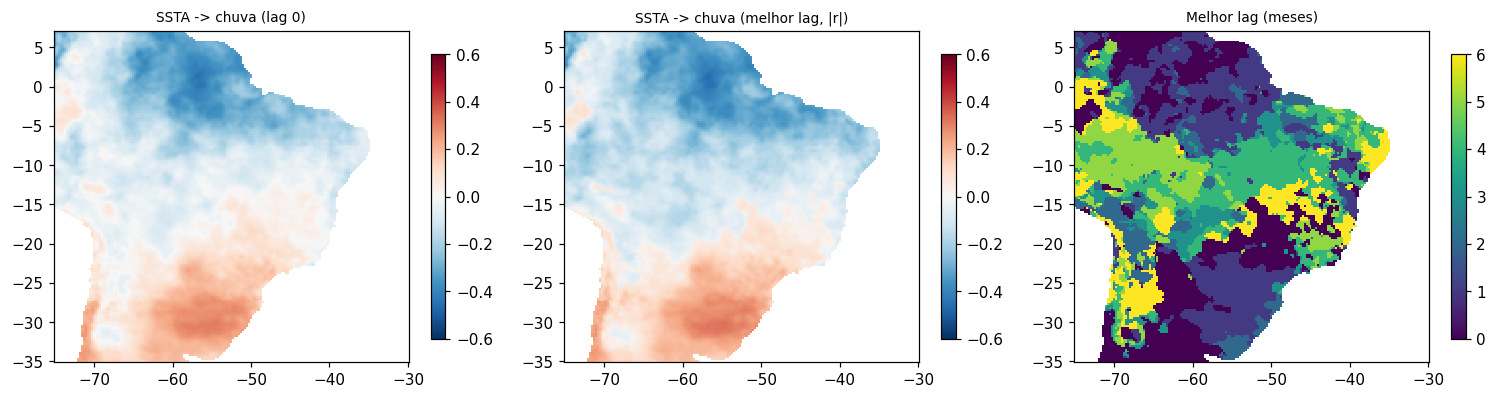

In [5]:
def draw(ax, da, title, vmin=-0.6, vmax=0.6, cmap="RdBu_r"):
    im = ax.pcolormesh(da.lon, da.lat, da, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(title, fontsize=9); ax.set_aspect("equal")
    return im

ssta_corr = corr_ds["nino34_ssta"]
# melhor lag por pixel (|corr| maximo)
abss = np.abs(ssta_corr)
valid2d = np.isfinite(ssta_corr.isel(lag=0))
arg = abss.fillna(-1.0).argmax("lag")            # sentinela evita argmax sobre all-NaN (oceano)
best_lag = ssta_corr.lag.values[arg.values]
best_lag = xr.DataArray(best_lag, coords={"lat": ssta_corr.lat, "lon": ssta_corr.lon},
                        dims=["lat","lon"]).where(valid2d)
best_r = ssta_corr.isel(lag=arg).where(valid2d)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = draw(axes[0], ssta_corr.sel(lag=0), "SSTA -> chuva (lag 0)")
im1 = draw(axes[1], best_r, "SSTA -> chuva (melhor lag, |r|)")
im2 = draw(axes[2], best_lag, "Melhor lag (meses)", vmin=0, vmax=6, cmap="viridis")
for im, ax in zip([im0, im1, im2], axes):
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.savefig(FIG / "phase4C_ssta_rain_corr.png", bbox_inches="tight"); plt.show()

## 5. Significancia de campo (p-valor por pixel + FDR)

                 metrica        valor
          pixels_validos 19431.000000
       pixels_signif_fdr  7792.000000
                %_signif    40.100000
lag_mediano_meses_signif     1.000000
         pixels_chuva(+)  2200.000000
          pixels_seca(-)  5592.000000
                 |r|_max     0.460204
[csv: phase4C_significance_summary.csv | nc: phase4C_best_lag_sig.nc]


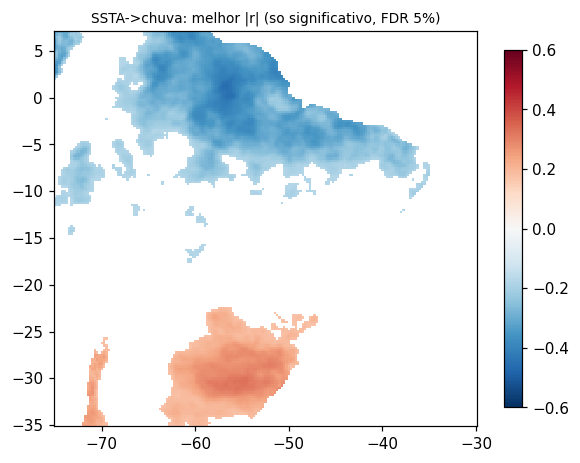

In [6]:
from scipy import stats
def corr_pvalue(r, n_eff):
    r = r.clip(-0.999, 0.999)
    t = r * np.sqrt((n_eff - 2) / (1 - r**2))
    return xr.apply_ufunc(lambda x: 2*stats.t.sf(np.abs(x), n_eff-2), t)

n = int(rain_anom.sizes["time"])
n_eff = max(10, n // 3)               # desconto grosseiro por autocorrelacao mensal
pmap = corr_pvalue(best_r, n_eff)
# FDR Benjamini-Hochberg sobre pixels validos
flat = pmap.values.ravel(); valid = np.isfinite(flat)
pv = flat[valid]; order = np.argsort(pv); m = len(pv)
thr = (np.arange(1, m+1) / m) * 0.05
passed = pv[order] <= thr
kmax = np.where(passed)[0].max() if passed.any() else -1
cut = pv[order][kmax] if kmax >= 0 else 0.0
sig = (pmap <= cut)
sgn = best_r.where(sig)
tab_signif = pd.DataFrame({"metrica":["pixels_validos","pixels_signif_fdr","%_signif","lag_mediano_meses_signif","pixels_chuva(+)","pixels_seca(-)","|r|_max"],
    "valor":[int(valid.sum()), int(sig.sum()), round(100*int(sig.sum())/max(int(valid.sum()),1),1),
             (float(best_lag.where(sig).median()) if int(sig.sum())>0 else np.nan), int((sgn>0).sum()), int((sgn<0).sum()),
             (float(np.abs(best_r.where(sig)).max()) if int(sig.sum())>0 else np.nan)]})
tab_signif.to_csv(F.STATS/"phase4C_significance_summary.csv", index=False)
xr.Dataset({"best_r":best_r,"best_lag":best_lag,"sig":sig.astype("int8")}).to_netcdf(NCOUT/"phase4C_best_lag_sig.nc")
print(tab_signif.to_string(index=False)); print("[csv: phase4C_significance_summary.csv | nc: phase4C_best_lag_sig.nc]")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.pcolormesh(best_r.lon, best_r.lat, best_r.where(sig), cmap="RdBu_r",
                   vmin=-0.6, vmax=0.6, shading="auto")
ax.set_title("SSTA->chuva: melhor |r| (so significativo, FDR 5%)", fontsize=9)
ax.set_aspect("equal"); fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.savefig(FIG / "phase4C_ssta_rain_sig.png", bbox_inches="tight"); plt.show()

## 6. Ranking de indices por |correlacao| media com a chuva do Brasil

In [7]:
rank_idx = []
for name, da in corr_maps.items():
    best = np.abs(da).max("lag")
    rank_idx.append((name, F.assign_block(name),
                     float(np.abs(best).mean()), float(np.abs(best).quantile(0.9))))
rank_idx = (pd.DataFrame(rank_idx, columns=["indice","block","abs_corr_media","abs_corr_p90"])
            .sort_values("abs_corr_media", ascending=False))
rank_idx.to_csv(F.STATS / "phase4C_index_rain_ranking.csv", index=False)
rank_idx

,indice,block,abs_corr_media,abs_corr_p90
5,nino34_ssta,sst,0.163696,0.311484
6,atm_10m_u_component_of_wind,wind,0.147671,0.238688
2,atm_mean_sea_level_pressure,pressure,0.129293,0.218776
4,ssh_nino34_mean_m,sea_level,0.127796,0.235388
0,ohc_0_300_nino34_j_m2,ocean_heat,0.124492,0.238633
3,sss_nino34_mean,salinity,0.094474,0.146476
1,wwv_equatorial_pacific_m3,ocean_heat,0.092882,0.156012


## Como interpretar (Objetivo 2)
- `phase4C_rain_nino_corr_maps.nc`: campos de correlacao (indice x lag x lat x lon).
- Mapas SSTA->chuva: o **Norte/Nordeste** tipicamente mostra correlacao negativa
  (El Nino -> seca) e o **Sul** positiva (El Nino -> mais chuva), com defasagem
  de 0-3 meses - confira no mapa de melhor-lag.
- `phase4C_ssta_rain_sig.png`: so os pixels que passam no controle FDR 5%.
- `phase4C_index_rain_ranking.csv`: quais indices do Nino tem maior correlacao
  media com a chuva do Brasil (SSTA e WWV costumam liderar).

### Mascara de terra (opcional, melhora os mapas)
Para mascarar oceano use `regionmask` (Natural Earth) ou os shapefiles IBGE em
`data/processed/geotiff/ibge`. Exemplo com regionmask:
```python
import regionmask
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
mask = land.mask(rain_anom.lon, rain_anom.lat) == 0  # 0 = terra
best_r = best_r.where(mask)
```
